Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data = pd.read_csv(r'/content/drive/MyDrive/titanic_dataset.csv', index_col='PassengerId')

Understand the data

In [4]:
data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
data.shape

(891, 11)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [7]:
data.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
data.describe(include='object')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


Handle the null values

In [9]:
data.isna().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,687


In [10]:
data['Age'] = data['Age'].fillna(data['Age'].median())

In [11]:

for val in ['Cabin','Embarked']:
  data[val] = data[val].fillna(data[val].mode()[0])

In [12]:
data.isna().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,0


Detect outliers

In [13]:
data1 = data.copy()

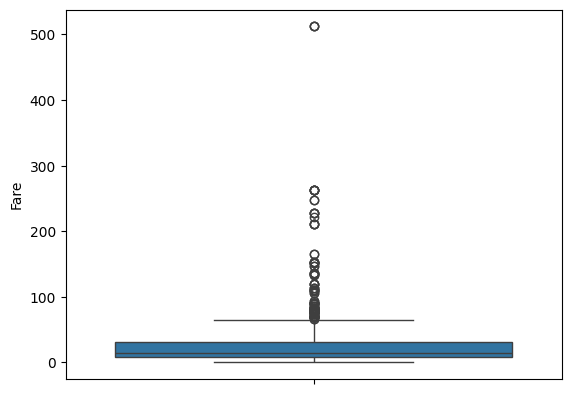

In [14]:
sns.boxplot(data1['Fare'])
plt.show()

In [15]:
q1 = np.percentile(data1['Fare'],25)
q2 = np.percentile(data1['Fare'],50)
q3 = np.percentile(data1['Fare'],75)
iqr = q3 - q1
print(iqr)

23.0896


In [16]:
low_lim = q1 - 1.5*iqr
upr_lim = q3 + 1.5*iqr
print(low_lim,upr_lim)

-26.724 65.6344


In [17]:
outliers = []
for x in data1['Fare']:
  if x > upr_lim or x < low_lim:
    outliers.append(x)

print(outliers)

[71.2833, 263.0, 146.5208, 82.1708, 76.7292, 80.0, 83.475, 73.5, 263.0, 77.2875, 247.5208, 73.5, 77.2875, 79.2, 66.6, 69.55, 69.55, 146.5208, 69.55, 113.275, 76.2917, 90.0, 83.475, 90.0, 79.2, 86.5, 512.3292, 79.65, 153.4625, 135.6333, 77.9583, 78.85, 91.0792, 151.55, 247.5208, 151.55, 110.8833, 108.9, 83.1583, 262.375, 164.8667, 134.5, 69.55, 135.6333, 153.4625, 133.65, 66.6, 134.5, 263.0, 75.25, 69.3, 135.6333, 82.1708, 211.5, 227.525, 73.5, 120.0, 113.275, 90.0, 120.0, 263.0, 81.8583, 89.1042, 91.0792, 90.0, 78.2667, 151.55, 86.5, 108.9, 93.5, 221.7792, 106.425, 71.0, 106.425, 110.8833, 227.525, 79.65, 110.8833, 79.65, 79.2, 78.2667, 153.4625, 77.9583, 69.3, 76.7292, 73.5, 113.275, 133.65, 73.5, 512.3292, 76.7292, 211.3375, 110.8833, 227.525, 151.55, 227.525, 211.3375, 512.3292, 78.85, 262.375, 71.0, 86.5, 120.0, 77.9583, 211.3375, 79.2, 69.55, 120.0, 93.5, 80.0, 83.1583, 69.55, 89.1042, 164.8667, 69.55, 83.1583]


In [18]:
ind = data1['Fare'] > upr_lim
data1.loc[ind].index

Index([  2,  28,  32,  35,  53,  62,  63,  73,  89, 103,
       ...
       793, 803, 821, 830, 836, 847, 850, 857, 864, 880],
      dtype='int64', name='PassengerId', length=116)

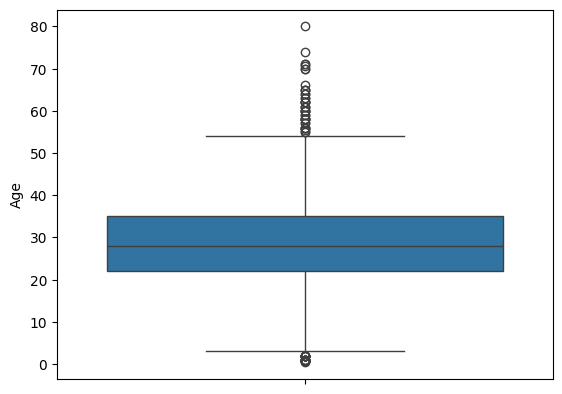

In [19]:
sns.boxplot(data1['Age'])
plt.show()

In [20]:
q1 = np.percentile(data1['Age'],25)
q2 = np.percentile(data1['Age'],50)
q3 = np.percentile(data1['Age'],75)
iqr = q3 - q1
print(iqr)

13.0


In [21]:
low_lim = q1 - 1.5*iqr
upr_lim = q3 + 1.5*iqr
print(low_lim,upr_lim)

2.5 54.5


In [22]:
outliers_age = []
for x in data1['Age']:
  if x > upr_lim or x < low_lim:
    outliers_age.append(x)

print(outliers_age)

[2.0, 58.0, 55.0, 2.0, 66.0, 65.0, 0.83, 59.0, 71.0, 70.5, 2.0, 55.5, 1.0, 61.0, 1.0, 56.0, 1.0, 58.0, 2.0, 59.0, 62.0, 58.0, 63.0, 65.0, 2.0, 0.92, 61.0, 2.0, 60.0, 1.0, 1.0, 64.0, 65.0, 56.0, 0.75, 2.0, 63.0, 58.0, 55.0, 71.0, 2.0, 64.0, 62.0, 62.0, 60.0, 61.0, 57.0, 80.0, 2.0, 0.75, 56.0, 58.0, 70.0, 60.0, 60.0, 70.0, 0.67, 57.0, 1.0, 0.42, 2.0, 1.0, 62.0, 0.83, 74.0, 56.0]


In [23]:
ind = data1['Age'] < low_lim
data1.loc[ind].index

Index([  8,  17,  79, 120, 165, 173, 184, 206, 298, 306, 341, 382, 387, 470,
       480, 531, 643, 645, 756, 789, 804, 825, 828, 832],
      dtype='int64', name='PassengerId')

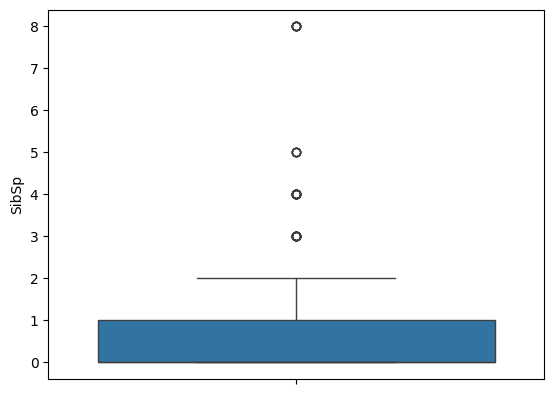

In [24]:
sns.boxplot(data1['SibSp'])
plt.show()

In [25]:
q1 = np.percentile(data1['SibSp'],25)
q2 = np.percentile(data1['SibSp'],50)
q3 = np.percentile(data1['SibSp'],75)
iqr = q3 - q1
print(iqr)

1.0


In [26]:
low_lim = q1 - 1.5*iqr
upr_lim = q3 + 1.5*iqr
print(low_lim,upr_lim)

-1.5 2.5


In [27]:
outliers_sib = []
for x in data1['SibSp']:
  if x > upr_lim or x < low_lim:
    outliers_sib.append(x)

print(outliers_sib)

[3, 4, 3, 3, 4, 5, 3, 4, 5, 3, 3, 4, 8, 4, 4, 3, 8, 4, 8, 3, 4, 4, 4, 4, 8, 3, 3, 5, 3, 5, 3, 4, 4, 3, 3, 5, 4, 3, 4, 8, 4, 3, 4, 8, 4, 8]


In [28]:
ind = data1['SibSp'] > upr_lim
data1.loc[ind].index

Index([  8,  17,  25,  28,  51,  60,  64,  69,  72,  86,  89, 120, 160, 165,
       172, 177, 181, 183, 202, 230, 234, 262, 267, 279, 325, 342, 375, 387,
       410, 481, 486, 542, 543, 635, 643, 684, 687, 727, 788, 793, 814, 820,
       825, 847, 851, 864],
      dtype='int64', name='PassengerId')

In [29]:
data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,B96 B98,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,B96 B98,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,B96 B98,S


Encode the categorical columns

In [30]:
x = data.drop(['Name','Ticket','Cabin','Survived'], axis=1)
y = data['Survived']

In [31]:
x = pd.get_dummies(x, dtype='int')

In [32]:
x.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,
1,3,22.0,1,0,7.2500,0,1,0,0,1
2,1,38.0,1,0,71.2833,1,0,1,0,0
3,3,26.0,0,0,7.9250,1,0,0,0,1
4,1,35.0,1,0,53.1000,1,0,0,0,1
5,3,35.0,0,0,8.0500,0,1,0,0,1


Scale the continuous numerical columns

In [33]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [34]:
x_train1 = x_train.drop(['Sex_female','Sex_male','Embarked_C','Embarked_Q','Embarked_S'], axis=1)
x_test1 = x_test.drop(['Sex_female','Sex_male','Embarked_C','Embarked_Q','Embarked_S'], axis=1)

In [35]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [36]:
x_train1_scaled = sc.fit_transform(x_train1)
x_test1_scaled = sc.transform(x_test1)

In [37]:
x_train1_scaled = pd.DataFrame(x_train1_scaled, columns=x_train1.columns)
x_test1_scaled = pd.DataFrame(x_test1_scaled, columns=x_test1.columns)

In [38]:
x_train_scaled = x_train.drop(['Pclass','Age','SibSp','Parch','Fare'], axis=1)
x_test_scaled = x_test.drop(['Pclass','Age','SibSp','Parch','Fare'], axis=1)

In [39]:
x_train_scaled = x_train_scaled.reset_index(drop=True)
x_train1_scaled = x_train1_scaled.reset_index(drop=True)
x_test_scaled = x_test_scaled.reset_index(drop=True)
x_test1_scaled = x_test1_scaled.reset_index(drop=True)

In [40]:
x_train_scaled = pd.concat([x_train_scaled, x_train1_scaled], axis=1)
x_test_scaled = pd.concat([x_test_scaled, x_test1_scaled], axis=1)

In [41]:
x_train_scaled

,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Pclass,Age,SibSp,Parch,Fare
0,0,1,0,0,1,-1.614136,1.253641,-0.470722,-0.479342,-0.078684
1,0,1,0,0,1,-0.400551,-0.477284,-0.470722,-0.479342,-0.377145
2,0,1,0,0,1,0.813034,0.215086,-0.470722,-0.479342,-0.474867
3,0,1,0,0,1,0.813034,-0.246494,0.379923,-0.479342,-0.476230
4,1,0,0,0,1,0.813034,-1.785093,2.931860,2.048742,-0.025249
...,...,...,...,...,...,...,...,...,...,...
707,1,0,0,0,1,0.813034,-0.631144,-0.470722,-0.479342,-0.480162
708,0,1,0,0,1,-1.614136,-0.092634,-0.470722,-0.479342,-0.030545
709,0,1,0,0,1,0.813034,0.907456,1.230569,-0.479342,-0.355804
710,1,0,0,0,1,-1.614136,-1.169653,0.379923,2.048742,1.683201


#### Logistic Regression

In [42]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [43]:
log_predictions = lr.predict(x_test_scaled)

In [44]:
log_accuracy = accuracy_score(y_test, log_predictions)
log_precision = precision_score(y_test, log_predictions)
log_recall = recall_score(y_test, log_predictions)
log_f1 = f1_score(y_test, log_predictions)

In [45]:
print("Logistic Regression Metrics Report\n")
print("Accuracy: ", log_accuracy)
print("Precision: ", log_precision)
print("Recall score: ", log_recall)
print("F1 score: ", log_f1)

Logistic Regression Metrics Report

Accuracy:  0.8100558659217877
Precision:  0.7857142857142857
Recall score:  0.7432432432432432
F1 score:  0.7638888888888888


In [46]:
confusion_matrix(y_test, log_predictions)

array([[90, 15],
       [19, 55]])

In [47]:
from sklearn.metrics import classification_report
print(classification_report(y_test, log_predictions))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



#### KNN Classifier

In [49]:
from sklearn.neighbors import KNeighborsClassifier
metric_k = []
neighbors = np.arange(3,16)

for k in neighbors:
  knn = KNeighborsClassifier(n_neighbors = k, metric='euclidean')
  knn = knn.fit(x_train_scaled, y_train)
  knn_predictions  = knn.predict(x_test_scaled)
  acc = accuracy_score(y_test, knn_predictions)
  metric_k.append(acc)

In [50]:
metric_k

[0.7988826815642458,
 0.7877094972067039,
 0.8100558659217877,
 0.8044692737430168,
 0.8268156424581006,
 0.8044692737430168,
 0.7988826815642458,
 0.7932960893854749,
 0.7988826815642458,
 0.7932960893854749,
 0.8044692737430168,
 0.8044692737430168,
 0.8100558659217877]

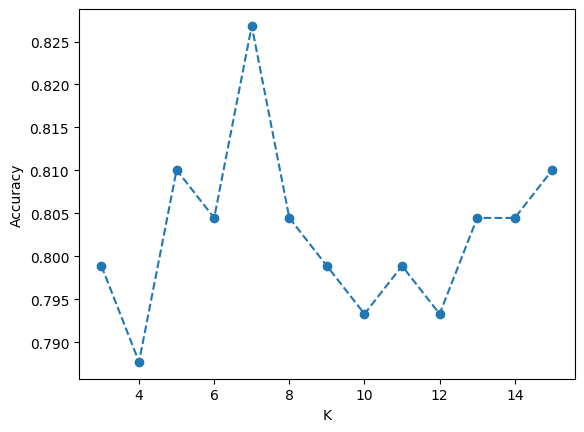

In [51]:
plt.plot(neighbors, metric_k, linestyle='dashed', marker='o')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.show()

In [53]:
knn_model = KNeighborsClassifier(n_neighbors=7, metric='euclidean')
knn_model.fit(x_train_scaled, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=7)

In [54]:
knn_predictions = knn_model.predict(x_test_scaled)

In [55]:
confusion_matrix(y_test, knn_predictions)

array([[93, 12],
       [19, 55]])

In [56]:
knn_accuracy = accuracy_score(y_test, knn_predictions)
knn_precision = precision_score(y_test, knn_predictions)
knn_recall = recall_score(y_test, knn_predictions)
knn_f1 = f1_score(y_test, knn_predictions)

In [57]:
print('KNN Metrics Report\n')
print('Accuracy: ', knn_accuracy)
print('Precision: ', knn_precision)
print('Recall score: ', knn_recall)
print('F1 score: ', knn_f1)

KNN Metrics Report

Accuracy:  0.8268156424581006
Precision:  0.8208955223880597
Recall score:  0.7432432432432432
F1 score:  0.7801418439716312


In [58]:
print(classification_report(y_test, knn_predictions))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86       105
           1       0.82      0.74      0.78        74

    accuracy                           0.83       179
   macro avg       0.83      0.81      0.82       179
weighted avg       0.83      0.83      0.83       179



#### SVM

In [59]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf')
svm_model.fit(x_train_scaled,y_train)

SVC()

In [60]:
svm_predictions = svm_model.predict(x_test_scaled)

In [61]:
svm_accuracy = accuracy_score(y_test, svm_predictions)
svm_precision = precision_score(y_test, svm_predictions)
svm_recall = recall_score(y_test, svm_predictions)
svm_f1 = f1_score(y_test, svm_predictions)

In [78]:
confusion_matrix(y_test, svm_predictions)

array([[92, 13],
       [20, 54]])

In [62]:
print("SVM Metrics Report\n")
print("Accuracy: ", svm_accuracy)
print("Precision: ", svm_precision)
print("Recall score: ", svm_recall)
print("F1 score: ", svm_f1)

SVM Metrics Report

Accuracy:  0.8156424581005587
Precision:  0.8059701492537313
Recall score:  0.7297297297297297
F1 score:  0.7659574468085106


In [63]:
print(classification_report(y_test, svm_predictions))

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       105
           1       0.81      0.73      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.81       179



#### Decision Tree

In [64]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth = 6, random_state = 42)
dt_model.fit(x_train_scaled, y_train)

DecisionTreeClassifier(max_depth=6, random_state=42)

In [65]:
dt_predictions = dt_model.predict(x_test_scaled)

In [66]:
dt_accuracy = accuracy_score(y_test, dt_predictions)
dt_precision = precision_score(y_test, dt_predictions)
dt_recall = recall_score(y_test, dt_predictions)
dt_f1 = f1_score(y_test, dt_predictions)

In [77]:
confusion_matrix(y_test, dt_predictions)

array([[96,  9],
       [26, 48]])

In [67]:
print("Decision Tree Metrics Report\n")
print("Accuracy: ", dt_accuracy)
print("Precision: ", dt_precision)
print("Recall score: ", dt_recall)
print("F1 score: ", dt_f1)

Decision Tree Metrics Report

Accuracy:  0.8044692737430168
Precision:  0.8421052631578947
Recall score:  0.6486486486486487
F1 score:  0.732824427480916


In [68]:
print(classification_report(y_test, dt_predictions))

              precision    recall  f1-score   support

           0       0.79      0.91      0.85       105
           1       0.84      0.65      0.73        74

    accuracy                           0.80       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.80      0.80       179



#### Random Forest

In [69]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators = 100, random_state=42)
rf_model.fit(x_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [70]:
rf_predictions = rf_model.predict(x_test_scaled)
confusion_matrix(y_test, rf_predictions)

array([[91, 14],
       [20, 54]])

In [71]:
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)

In [72]:
print("Random Forest Metrics Report\n")
print("Accuracy: ", rf_accuracy)
print("Precision: ", rf_precision)
print("Recall score: ", rf_recall)
print("F1 score: ", rf_f1)

Random Forest Metrics Report

Accuracy:  0.8100558659217877
Precision:  0.7941176470588235
Recall score:  0.7297297297297297
F1 score:  0.7605633802816901


In [73]:
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.82      0.87      0.84       105
           1       0.79      0.73      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



Model Comparison

In [74]:
results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "SVM"
    ],

    "Accuracy": [
        log_accuracy,
        knn_accuracy,
        dt_accuracy,
        rf_accuracy,
        svm_accuracy
    ],

    "Precision": [
        log_precision,
        knn_precision,
        dt_precision,
        rf_precision,
        svm_precision
    ],

    "Recall": [
        log_recall,
        knn_recall,
        dt_recall,
        rf_recall,
        svm_recall
    ],

    "F1 Score": [
        log_f1,
        knn_f1,
        dt_f1,
        rf_f1,
        svm_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.810056,0.785714,0.743243,0.763889
1,KNN,0.826816,0.820896,0.743243,0.780142
2,Decision Tree,0.804469,0.842105,0.648649,0.732824
3,Random Forest,0.810056,0.794118,0.729730,0.760563
4,SVM,0.815642,0.805970,0.729730,0.765957


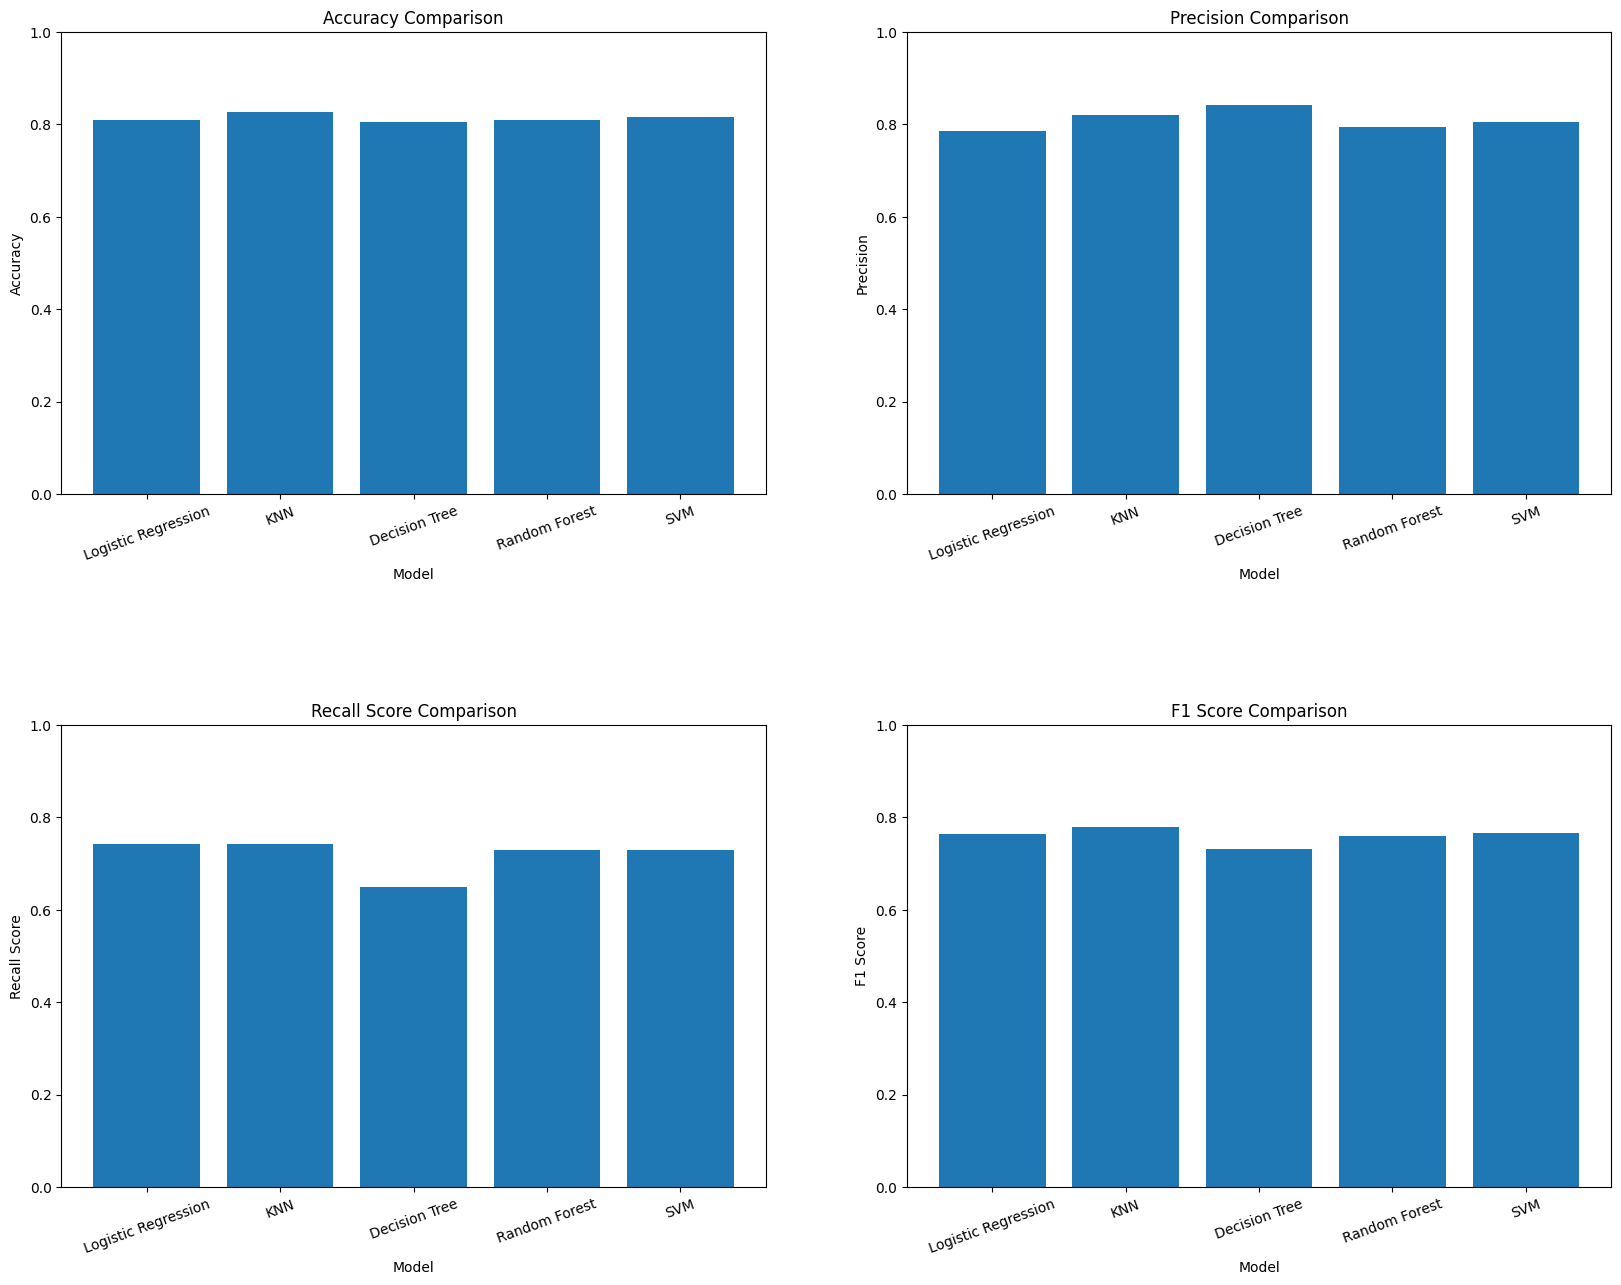

In [76]:
plt.figure(figsize=(20,15))
plt.subplot(2,2,1)
plt.bar(
    results["Model"],
    results["Accuracy"]
)
plt.title("Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20)

plt.subplot(2,2,2)
plt.bar(
    results["Model"],
    results["Precision"]
)
plt.title("Precision Comparison")
plt.xlabel("Model")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.xticks(rotation=20)

plt.subplots_adjust(hspace=0.5)

plt.subplot(2,2,3)
plt.bar(
    results["Model"],
    results["Recall"]
)
plt.title("Recall Score Comparison")
plt.xlabel("Model")
plt.ylabel("Recall Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)

plt.subplot(2,2,4)
plt.bar(
    results["Model"],
    results["F1 Score"]
)
plt.title("F1 Score Comparison")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)

plt.show()

In terms of accuracy, KNN is the best model among the other classification models.